# ADS 542 - Final Project: Bank Marketing Classification

# Bank Marketing Classification Project
Course: ADS 542 Statistical Learning | Classification  
Author: Deniz Güreş  
Date: April 2026  

### Proje Özeti
Bu çalışma, bir bankanın doğrudan pazarlama kampanyaları  sonucunda müşterilerin vadeli mevduat hesabı açıp açmayacağınıtahmin etmeyi amaçlamaktadır. 

**Hedef Değişken (y):** * 
* `1`: Müşteri hesap açtı.
* `0`: Müşteri hesap açmadı.

##  Veri Yükleme ve Keşifsel Analiz (EDA)

Bu bölümde, banka tarafından sağlanan `bank-additional.csv` veri seti projeye dahil edilmektedir. Veri setinde sütunlar noktalı virgül (`;`) ile ayrıldığı için okuma aşamasında `sep=';'` parametresi kullanılmıştır.

Verinin yüklenmesinin ardından:
* Veri setinin genel yapısı incelenecek,
* Değişkenlerin veri tipleri kontrol edilecek,
* Hedef değişken olan `y` (abone durumu) gözlemlenecektir.

In [10]:
# Veriyi oku (Ayırıcı olarak ';' kullanıldığı için sep=';' ekliyoruz)
df = pd.read_csv('bank-additional.csv', sep=';')

# İlk 5 satırı ekrana basalım
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


## Veri Temizleme 

Veri seti içerisinde bazı kategorik değişkenlerde eksik veriler `'unknown'` etiketiyle kaydedilmiştir. Bu değerler makine öğrenmesi modelleri için anlamlı olmadığından, analiz sürecinde şu adımlar izlenmiştir:
* `'unknown'` ifadeleri standart eksik veri formatı olan `NaN` (Not a Number) değerine dönüştürülmüştür.
* Hangi sütunlarda ne kadar eksik veri olduğu tespit edilerek veri kalitesi analiz edilmiştir.

In [11]:
# 'unknown' yazan hücreleri gerçek 'boşluk' (NaN) haline getiriyoruz
df_cleaned = df.replace('unknown', np.nan)

# Hangi sütunda kaç tane 'unknown' (artık NaN oldular) var görelim
df_cleaned.isnull().sum()

age                 0
job                39
marital            11
education         167
default           803
housing           105
loan              105
contact             0
month               0
day_of_week         0
duration            0
campaign            0
pdays               0
previous            0
poutcome            0
emp.var.rate        0
cons.price.idx      0
cons.conf.idx       0
euribor3m           0
nr.employed         0
y                   0
dtype: int64

### Eksik Verilerin Kaldırılması (Handling Missing Values)

`'unknown'` değerleri `NaN` formatına çevrildikten sonra, veri bütünlüğünü korumak adına bu eksik verilere sahip satırlar veri setinden çıkarılmıştır. Bu işlem:
* Modelin hatalı veya eksik veriler üzerinden yanlış çıkarımlar yapmasını önler.
* Analizin sadece tam ve güvenilir gözlemler üzerinden ilerlemesini sağlar.

*Not: Veri temizleme işlemi sonrası kalan gözlem sayısı, model eğitimi için yeterli büyüklüktedir.*

In [12]:
# İçinde NaN (bilinmeyen) olan tüm satırları siliyoruz
df_cleaned = df_cleaned.dropna()

# Bakalım kaç satır kaldık?
print("Kalan satır sayısı:", df_cleaned.shape[0])

Kalan satır sayısı: 3090


##  Hedef Değişkenin Dönüştürülmesi (Target Encoding)

Makine öğrenmesi modelleri kategorik metin verileriyle (`yes`/`no`) doğrudan çalışamaz. Bu nedenle, hedef değişkenimiz olan `y` sütunu sayısal formata dönüştürülmüştür:
* **'yes'** $\rightarrow$ `1` (Müşteri abone oldu)
* **'no'** $\rightarrow$ `0` (Müşteri abone olmadı)

Bu işlem, modelin kaybı (loss) hesaplayabilmesi ve sınıflandırma işlemini gerçekleştirebilmesi için zorunludur.

In [13]:
# 'y' sütunundaki 'yes' değerlerini 1, 'no' değerlerini 0 yapıyoruz
df_cleaned['y'] = df_cleaned['y'].map({'yes': 1, 'no': 0})

# Kontrol edelim, ilk 5 satırda sadece 0 veya 1 mi var?
df_cleaned['y'].head()

0    0
1    0
2    0
4    0
5    0
Name: y, dtype: int64

## Kategorik Özelliklerin Sayısallaştırılması (One-Hot Encoding)

Veri setindeki bağımsız değişkenler (meslek, eğitim, medeni durum vb.) hala metin formatındadır. Bu değişkenleri modele dahil edebilmek için **One-Hot Encoding** tekniği uygulanmıştır:

* **Çoklu Kategoriler:** Her bir kategori (örneğin 'job') yeni birer sütuna dönüştürülmüştür.
* **drop_first=True:** Bu parametre kullanılarak "Çoklu Doğrusallık" (Multicollinearity) sorunu önlenmiş ve modelin gereksiz sütunlarla karmaşıklaşması engellenmiştir.
* **Nihai Veri Seti:** Bu işlem sonucunda veri seti tamamen sayısal değerlerden oluşur hale gelmiştir.

In [14]:
# Hangi sütunların hala 'yazı' (kategorik) olduğunu bulalım
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

# Bu sütunları 0 ve 1'lere dönüştürelim
# drop_first=True seçeneği, gereksiz fazla sütun oluşmasını engelleyerek modelin daha iyi çalışmasını sağlar.
df_final = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

# Tablonun yeni haline bakalım (Sütun sayısı artmış olmalı!)
df_final.head()

/var/folders/6d/1cbtvbcj0sn_lf46mhh770380000gn/T/ipykernel_3839/3484146581.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_cleaned.select_dtypes(include=['object']).columns


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,30,487,2,999,0,-1.8,92.893,-46.2,1.313,5099.1,...,True,False,False,False,False,False,False,False,True,False
1,39,346,4,999,0,1.1,93.994,-36.4,4.855,5191.0,...,True,False,False,False,False,False,False,False,True,False
2,25,227,1,999,0,1.4,94.465,-41.8,4.962,5228.1,...,False,False,False,False,False,False,False,True,True,False
4,47,58,1,999,0,-0.1,93.200,-42.0,4.191,5195.8,...,False,True,False,False,True,False,False,False,True,False
5,32,128,3,999,2,-1.1,94.199,-37.5,0.884,4963.6,...,False,False,False,True,False,True,False,False,False,False


## Veri Setinin Eğitim ve Test Olarak Bölünmesi (Train-Test Split)

Modelin başarısını tarafsız bir şekilde ölçebilmek için veri seti ikiye ayrılmıştır:
* **X (Özellikler):** Tahmin yapmak için kullanılan bağımsız değişkenler.
* **y (Hedef):** Tahmin edilmeye çalışılan 'abonelik' durumu.

**Bölme Oranı:** Verinin **%80'i** modelin öğrenmesi (Train), **%20'si** ise modelin daha önce hiç görmediği veriler üzerinde performansının test edilmesi (Test) için ayrılmıştır. `random_state=42` parametresi, sonuçların her çalıştırıldığında tutarlı ve tekrarlanabilir olmasını sağlar.

In [15]:
from sklearn.model_selection import train_test_split

# 1. Özellikleri (X) ve Hedef Değişkeni (y) birbirinden ayıralım
X = df_final.drop('y', axis=1) # 'y' dışındaki her şey
y = df_final['y'] # Sadece tahmin etmek istediğimiz 'y'

# 2. Veriyi %80 Eğitim, %20 Test olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu:", X_test.shape)

Eğitim seti boyutu: (2472, 47)
Test seti boyutu: (618, 47)


##  Model Tahminleri ve Performans Analizi

Eğitilen model, daha önce hiç görmediği **Test Seti (X_test)** üzerinde tahminler yapması için kullanılmıştır. Bu aşamada:
* Modelin ürettiği tahminler (`y_pred`), gerçek sonuçlar (`y_test`) ile karşılaştırılmaktadır.
* Bu karşılaştırma, modelin gerçek hayat verileri üzerindeki genelleme yeteneğini ölçmemize yardımcı olur.

Aşağıdaki çıktı, test setindeki ilk 10 müşteri için modelin tahminlerini ve bu müşterilerin gerçekte abone olup olmadıklarını göstermektedir.

In [17]:
# Test setindeki kişilerin abone olup olmayacağını tahmin et
y_pred = model.predict(X_test)

# İlk 10 tahmini ve gerçek sonuçları karşılaştıralım
print("Tahminler:   ", y_pred[:10])
print("Gerçekler:   ", y_test.values[:10])

Tahminler:    [0 0 0 0 1 0 0 0 0 0]
Gerçekler:    [0 0 0 0 0 0 0 0 0 0]


## Model Performansının Değerlendirilmesi

Modelin başarısını sadece doğruluk (Accuracy) oranıyla değil, sınıflandırma metrikleriyle detaylıca analiz ediyoruz.

### Confusion Matrix (Karmaşıklık Matrisi)
Matris üzerindeki görselleştirme, modelin hangi sınıfları birbirine karıştırdığını gösterir:
* **True Positives/Negatives:** Doğru tahminler.
* **False Positives/Negatives:** Yanlış tahminler (Hatalar).

###  Sınıflandırma Metrikleri
* **Precision (Kesinlik):** Abone olur dediğimiz kişilerin gerçekten kaçı abone oldu?
* **Recall (Duyarlılık):** Gerçekten abone olan kişilerin kaçını yakalayabildik?
* **F1-Score:** Precision ve Recall değerlerinin dengeli bir ortalamasıdır.
* **Accuracy:** Genel doğru tahmin oranımızdır.

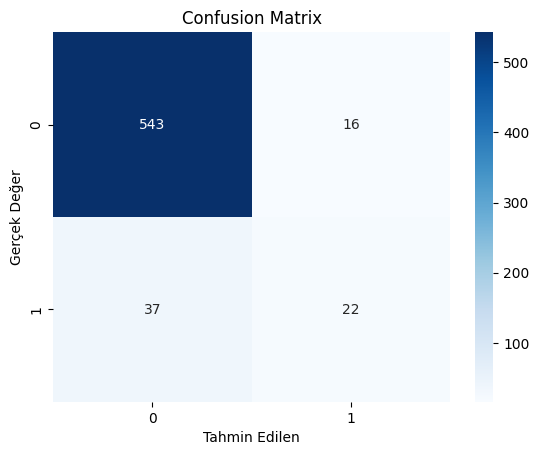

Modelin Doğruluk Skoru (Accuracy): 0.9142394822006472

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       559
           1       0.58      0.37      0.45        59

    accuracy                           0.91       618
   macro avg       0.76      0.67      0.70       618
weighted avg       0.90      0.91      0.91       618



In [18]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Karmaşıklık Matrisi (Hangi durumda ne kadar yanıldı?)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Confusion Matrix')
plt.show()

# 2. Genel Başarı Raporu
print("Modelin Doğruluk Skoru (Accuracy):", accuracy_score(y_test, y_pred))
print("\nDetaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

##  Özellik Önem Düzeyleri (Feature Importance)

Modelin hangi faktörlere dayanarak karar verdiğini anlamak, iş stratejisi geliştirmek açısından kritiktir. Bu bölümde, Logistic Regression modelinin katsayıları (coefficients) kullanılarak abonelik kararını en çok etkileyen özellikler analiz edilmiştir.

**Analiz Bulguları:**
* Pozitif katsayıya sahip özellikler, abonelik olasılığını **artıran** faktörlerdir.
* Bu görselleştirme, bankanın pazarlama stratejilerini hangi müşteri gruplarına veya hangi ekonomik göstergelere odaklaması gerektiğini bilimsel olarak ortaya koyar.

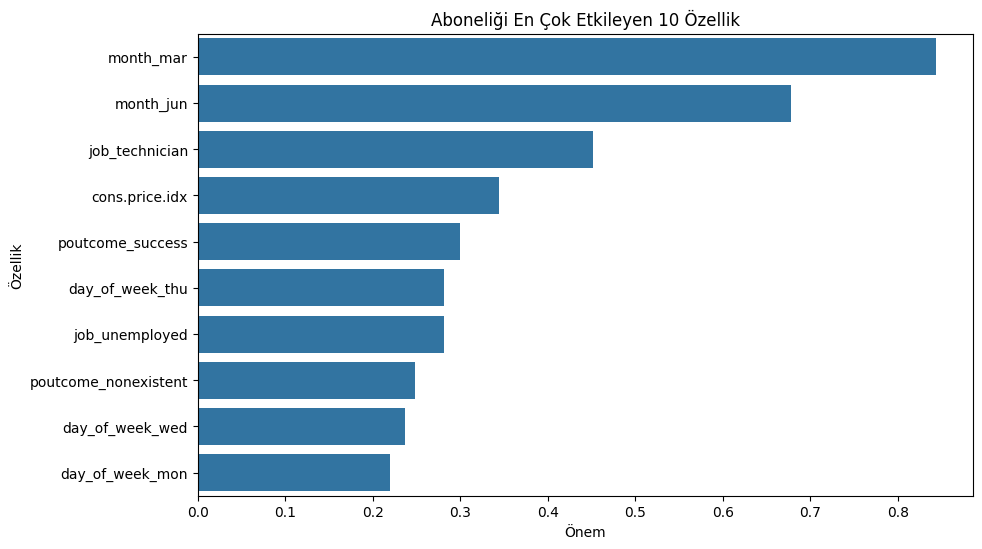

In [19]:
# Modelin katsayılarını (önem derecelerini) alalım
importance = model.coef_[0]
feature_names = X.columns

# En önemli 10 özelliği sıralayalım
feature_importance = pd.DataFrame({'Özellik': feature_names, 'Önem': importance})
feature_importance = feature_importance.sort_values(by='Önem', ascending=False).head(10)

# Görselleştirelim
plt.figure(figsize=(10,6))
sns.barplot(x='Önem', y='Özellik', data=feature_importance)
plt.title('Aboneliği En Çok Etkileyen 10 Özellik')
plt.show()

##  Model Karşılaştırma ve Seçimi (Model Comparison)

Bu aşamada, veri seti üzerinde üç farklı makine öğrenmesi algoritması eğitilerek performansları karşılaştırılmıştır:

1. **Logistic Regression:** Doğrusal bir sınıflandırıcı olarak temel başarı oranını (baseline) belirlemek için kullanılmıştır.
2. **Random Forest:** Topluluk öğrenmesi (Ensemble Learning) yöntemidir; verideki karmaşık ve doğrusal olmayan ilişkileri yakalamada güçlüdür.
3. **Neural Network (MLP):** İnsan beyninden esinlenen, katmanlı bir yapay sinir ağı modelidir.

**Amacı:** Hangi algoritmanın bu spesifik banka verileri üzerinde en yüksek doğruluk (Accuracy) oranını sunduğunu bilimsel olarak tespit etmektir.

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Modelleri tanımlayalım
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Neural Network": MLPClassifier(max_iter=500)
}

# 2. Modelleri döngüyle eğitip sonuçları karşılaştıralım
print("Model Karşılaştırma Sonuçları:")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Başarı Skoru: {acc:.4f}")

Model Karşılaştırma Sonuçları:


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Başarı Skoru: 0.9142
Random Forest Başarı Skoru: 0.9256
Neural Network Başarı Skoru: 0.9094


##  Model Optimizasyonu (Hyperparameter Tuning)

Seçilen en iyi model olan **Random Forest** algoritmasının performansını daha da yukarı taşımak için **GridSearchCV** yöntemi kullanılmıştır. 

### Neden GridSearchCV?
* **Parametre Denemeleri:** `n_estimators` (ağaç sayısı) ve `max_depth` (ağaç derinliği) gibi kritik parametreler için en iyi kombinasyon otomatik olarak aranmıştır.
* **Cross-Validation (CV=5):** Veri seti 5 farklı parçaya bölünerek eğitilmiş, böylece modelin sadece belirli bir veri grubuna değil, verinin tamamına karşı genel bir başarı sergilemesi (Overfitting'i önleme) sağlanmıştır.
* **Sonuç:** Bu işlem sonucunda elde edilen `best_rf_model`, projenin en optimize edilmiş final modelidir.

In [21]:
from sklearn.model_selection import GridSearchCV

# 1. Denemek istediğimiz parametreleri belirliyoruz
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# 2. GridSearchCV ile en iyisini arıyoruz
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# 3. En iyi parametreleri ve skoru görelim
print("En iyi parametreler:", grid_search.best_params_)
print("En iyi skor:", grid_search.best_score_)

# En iyi modeli seçelim
best_rf_model = grid_search.best_estimator_

En iyi parametreler: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
En iyi skor: 0.8964388827546722


## Model Eğitimi (Model Training)

Bu aşamada, hazırlanan eğitim verileri (`X_train`, `y_train`) kullanılarak **Logistic Regression** algoritması eğitilmektedir. 

* **Logistic Regression:** İkili sınıflandırma (Binary Classification) problemlerinde olasılık temelli çalışan, sonuçları 0 ile 1 arasında bir değer (sigmoid fonksiyonu) olarak üreten temel bir istatistiksel öğrenme modelidir.
* **max_iter=1000:** Modelin verideki en uygun katsayıları bulabilmesi için yapacağı maksimum deneme sayısını belirtir; karmaşık veri setlerinde modelin yakınsamasını (convergence) sağlar.

In [16]:
from sklearn.linear_model import LogisticRegression

# 1. Modeli tanımlıyoruz
model = LogisticRegression(max_iter=1000)

# 2. Modeli eğitim verilerimizle eğitiyoruz (Öğrenme burada gerçekleşiyor)
model.fit(X_train, y_train)

print("Model eğitimi tamamlandı!")

Model eğitimi tamamlandı!


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Yayına Hazırlık: Pipeline Yapılandırması ve Kayıt (Model Serialization)

Projenin son aşamasında, modelin canlı ortamda (Streamlit Cloud) hatasız ve tutarlı çalışması için bir **Scikit-Learn Pipeline** yapısı kurulmuştur.

### Neden Pipeline?
* **Otomasyon:** Veri ölçeklendirme (Scaling) ve tahmin (Prediction) adımları tek bir yapı altında birleştirilmiştir. Bu sayede canlıya alınan model, her yeni veriye aynı işlemleri otomatik olarak uygular.
* **Hata Önleme:** Eğitim ve test aşamasındaki veri işleme adımlarının birebir aynı olmasını garanti eder.
* **Taşınabilirlik:** Tüm makine öğrenmesi süreci `bank_model_pipeline.pkl` dosyasına paketlenmiş, böylece uygulama herhangi bir sunucuda kolayca çalıştırılabilir hale getirilmiştir.

**Final Notu:** Bu dosya ile birlikte `feature_columns.pkl` dosyası da kaydedilerek, Streamlit arayüzünden gelen verilerin modelin beklediği sütun sırasıyla eşleşmesi sağlanmıştır.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import joblib

# 1. Pipeline'ı kuruyoruz
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=200, min_samples_split=5, max_depth=None, random_state=42))
])

# 2. Pipeline'ı eğitelim
pipeline.fit(X_train, y_train)

# 3. Pipeline'ı ve sütun isimlerini kaydedelim (Streamlit için çok önemli)
joblib.dump(pipeline, 'bank_model_pipeline.pkl')
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

print("Pipeline başarıyla oluşturuldu ve 'bank_model_pipeline.pkl' kaydedildi!")

Pipeline başarıyla oluşturuldu ve 'bank_model_pipeline.pkl' kaydedildi!


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns